# Baseline Models Training

Train baseline models with **strict time limits** per project plan:
- **Naive baselines**: Last-value and mean (fast, no limit)
- **LSTM**: Maximum hours hard cap

**Prerequisites**: Phase 2 Hyperpramater Tuning completed

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import time
import torch
import random
from tqdm.auto import tqdm
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, Callback
from darts import TimeSeries
from darts.models import BlockRNNModel
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logging.getLogger("darts").setLevel(logging.ERROR)

if os.path.basename(os.getcwd()) == 'notebooks':
    project_root = os.path.abspath('..')
else:
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.append(project_root)

from src.datamodule import smoothed_smape

sns.set_style('whitegrid')
%matplotlib inline

## 1. Configuration

In [2]:
logging.info("--- Setting up configuration ---")

BASE_DIR = ".."
DATA_DIR = os.path.join(BASE_DIR, "data")
TRAIN_DIR = os.path.join(DATA_DIR, "train_continuous")
VAL_DIR = os.path.join(DATA_DIR, "val_continuous")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(MODELS_DIR, exist_ok=True)

INPUT_CHUNK_LENGTH = 48
OUTPUT_CHUNK_LENGTH = 10
TARGET_COLS = ["high", "low", "close", "volume"]
SEED = 827
MAX_NUMBER_FILES = 2500 # Number of Asset Files to load
MAX_TRAINING_TIME_HOURS = 1

with open(os.path.join(RESULTS_DIR, "best_params_lstm.json"), "r") as f:
    BEST_LSTM_PARAMS = json.load(f)

logging.info(f"LSTM time limit: {MAX_TRAINING_TIME_HOURS} hours")
logging.info(f"Best LSTM params from tuning: {BEST_LSTM_PARAMS}")

[INFO] --- Setting up configuration ---
[INFO] LSTM time limit: 1 hours
[INFO] Best LSTM params from tuning: {'hidden_dim': 128, 'n_rnn_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 128}


## 2. Time Limit Callback

In [3]:
class TimeLimitCallback(Callback):
    def __init__(self, max_time_seconds):
        super().__init__()
        self.max_time_seconds = max_time_seconds
        self.start_time = None
        self.history = []
        
    def on_train_start(self, trainer, pl_module):
        self.start_time = time.time()
        self.history = [] # Reset history at the start of training
        logging.info(f"Time limit: {self.max_time_seconds/3600:.1f} hours")
        
    def on_train_epoch_end(self, trainer, pl_module):
        elapsed = time.time() - self.start_time
        if elapsed >= self.max_time_seconds:
            logging.info(f"Time limit reached: {elapsed/3600:.2f}h")
            trainer.should_stop = True

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        epoch_logs = {
            'train_loss': metrics.get('train_loss'),
            'val_loss': metrics.get('val_loss')
        }
        # Ensure metrics are available and are tensors before calling .item()
        if isinstance(epoch_logs['train_loss'], torch.Tensor) and isinstance(epoch_logs['val_loss'], torch.Tensor):
            train_loss_val = epoch_logs['train_loss'].item()
            val_loss_val = epoch_logs['val_loss'].item()
            self.history.append({
                'epoch': trainer.current_epoch,
                'train_loss': train_loss_val,
                'val_loss': val_loss_val
                })
            logging.info(f"Epoch {trainer.current_epoch}: Train Loss = {train_loss_val:.4f}, Val Loss = {val_loss_val:.4f}")

print("Time limit callback ready")

Time limit callback ready


## 3. Data Loading Functions

In [4]:
logging.info("--- Loading and preparing data ---")

# Get all parquet files from the training directory
train_files = {f for f in os.listdir(TRAIN_DIR) if f.endswith('.parquet')}
val_files = {f for f in os.listdir(VAL_DIR) if f.endswith('.parquet')}

common_files = sorted(list(train_files.intersection(val_files)))

random.seed(SEED)
random.shuffle(common_files)

common_files = common_files[:MAX_NUMBER_FILES]

PAST_COVARIATES = [
    'is_trading',
    'close_lag_adj_1',
    'close_delta_adj_1',
    'volume_adj_1',
    'close_lag_adj_2',
    'close_delta_adj_2',
    'volume_adj_2',
    'close_lag_adj_3',
    'close_delta_adj_3',
    'volume_adj_3',
    'close_lag_adj_4',
    'close_delta_adj_4',
    'volume_adj_4',
    'close_lag_adj_5',
    'close_delta_adj_5',
    'volume_adj_5',
    'close_lag_adj_6',
    'close_delta_adj_6',
    'volume_adj_6',
    'nearest_liquid_contract_close',
    'cross_contract_mean',
]
FUTURE_COVARIATES = [
    'time_to_delivery',
    'hour_of_day',
    'day_of_week',
    'week_of_year',
    'month',
    'is_weekend',
]

logging.info(f"Found {len(PAST_COVARIATES)} past covariates to use.")
logging.info(f"Found {len(FUTURE_COVARIATES)} future covariates to use.")

# Create TimeSeries objects with the covariates
assets_data = {}
for f in tqdm(common_files, desc="Processing asset files"):
    asset_name = f.replace('.parquet', '')
    train_path = os.path.join(TRAIN_DIR, f)
    val_path = os.path.join(VAL_DIR, f)

    if not os.path.exists(val_path):
        logging.warning(f"Validation file not found for {asset_name}, skipping asset.")
        continue

    train_df = pd.read_parquet(train_path)
    val_df = pd.read_parquet(val_path)

    if len(train_df) < INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH or len(val_df) < INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH:
        logging.warning(f"Insufficient data for {asset_name}, skipping asset.")
        continue

    for df in [train_df, val_df]:
        df['ExecutionTime'] = pd.to_datetime(df['ExecutionTime']).dt.tz_localize(None)
        for col in TARGET_COLS + PAST_COVARIATES + FUTURE_COVARIATES:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        numeric_cols = df.select_dtypes(include=np.number).columns
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0)
        df[numeric_cols] = df[numeric_cols].astype(np.float32)


    train_indexed = train_df.set_index('ExecutionTime')
    val_indexed = val_df.set_index('ExecutionTime')

        
    # Now create TimeSeries from filled DataFrames
    train_ts = TimeSeries.from_dataframe(train_indexed[TARGET_COLS], freq='15min')
    val_ts = TimeSeries.from_dataframe(val_indexed[TARGET_COLS], freq='15min')
        
    past_cov_train = TimeSeries.from_dataframe(train_indexed[PAST_COVARIATES], freq='15min')
    past_cov_val = TimeSeries.from_dataframe(val_indexed[PAST_COVARIATES], freq='15min')
    future_cov_train = TimeSeries.from_dataframe(train_indexed[FUTURE_COVARIATES], freq='15min')
    future_cov_val = TimeSeries.from_dataframe(val_indexed[FUTURE_COVARIATES], freq='15min')
        
    assets_data[asset_name] = {
        'train_ts': train_ts,
        'val_ts': val_ts,
        'past_cov_train': past_cov_train,
        'past_cov_val': past_cov_val,
        'future_cov_train': future_cov_train,
        'future_cov_val': future_cov_val
    }

logging.info(f"Successfully loaded and processed {len(assets_data)} assets.")

[INFO] --- Loading and preparing data ---
[INFO] Found 21 past covariates to use.
[INFO] Found 6 future covariates to use.


Processing asset files:   0%|          | 0/2500 [00:00<?, ?it/s]

[INFO] Successfully loaded and processed 2500 assets.


## 4. Naive Baselines

In [5]:
def evaluate_with_smape(predictions, actuals):
    """Evaluate predictions using masked sMAPE metric.
    
    Args:
        predictions: List of TimeSeries predictions
        actuals: List of TimeSeries actuals  
        masks: Optional list of masks (1 for trading, 0 for non-trading)
    """
    results = {t: [] for t in TARGET_COLS}
    for i, (pred, actual) in enumerate(zip(predictions, actuals)):
        # Use .values() to get numpy array [timesteps, n_features]
        pred_vals = pred.values()
        actual_vals = actual.values()
        
        # Skip if contains NaN or inf
        if np.isnan(pred_vals).any() or np.isnan(actual_vals).any():
            continue
        if np.isinf(pred_vals).any() or np.isinf(actual_vals).any():
            continue
        
        for idx, target in enumerate(TARGET_COLS):
            # Extract values for this target
            pred_target = pred_vals[:, idx]
            actual_target = actual_vals[:, idx]
            
            # Convert to torch tensors with shape [B=1, T, F=1]
            pred_t = torch.tensor(pred_target, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            actual_t = torch.tensor(actual_target, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            
            # Use provided mask or create a simple validity mask
            smape = smoothed_smape(actual_t, pred_t)
            if not torch.isnan(smape) and not torch.isinf(smape):
                results[target].append(float(smape.item()) * 100)
    
    # Return mean, handling empty lists
    return {t: np.mean(v) if len(v) > 0 else np.nan for t, v in results.items()}

def last_value_forecast(series, n):
    """Create naive forecast by repeating last value."""
    # Get last values using .values() which returns [timesteps, n_features]
    last_vals = series.values()[-1, :]
    
    # Tile to create n timesteps
    vals = np.tile(last_vals, (n, 1))
    
    # Create time index
    idx = pd.date_range(series.end_time() + series.freq, periods=n, freq=series.freq)
    
    # Create dataframe and return as TimeSeries
    df = pd.DataFrame(vals, index=idx, columns=series.components)
    return TimeSeries.from_dataframe(df, freq=series.freq)

def find_first_valid_index(ts, input_length):
    """Find first index where we have enough non-zero data for forecasting."""
    vals = ts.values()
    # Look for first position where we have input_length consecutive non-all-zero rows
    for i in range(len(vals) - input_length):
        window = vals[i:i+input_length]
        # Check if at least one price column (high/low/close) has non-zero values
        if np.any(window[:, :3] > 0):  # Check first 3 columns (high, low, close)
            return i
    return 0

# Run naive baseline evaluation
print("Evaluating naive baseline (last-value forecast)...")
naive_results = {}
debug_info = {}

for name, data in assets_data.items():
    preds, acts = [], []
    val_len = len(data['val_ts'])
    
    # Find first valid starting position (skip initial zeros)
    start_idx = find_first_valid_index(data['val_ts'], INPUT_CHUNK_LENGTH)
    
    # Generate forecasts over validation set, starting from valid data
    for i in range(start_idx, min(500 + start_idx, val_len - INPUT_CHUNK_LENGTH), OUTPUT_CHUNK_LENGTH):
        ctx = data['val_ts'][:INPUT_CHUNK_LENGTH + i]
        pred = last_value_forecast(ctx, OUTPUT_CHUNK_LENGTH)
        actual = data['val_ts'][INPUT_CHUNK_LENGTH + i:INPUT_CHUNK_LENGTH + i + OUTPUT_CHUNK_LENGTH]
        
        if len(actual) == OUTPUT_CHUNK_LENGTH:
            preds.append(pred)
            acts.append(actual)
    
    if preds and acts:
        asset_results = evaluate_with_smape(preds, acts)
        naive_results[name] = asset_results
        debug_info[name] = {
            'num_predictions': len(preds),
            'start_idx': start_idx,
            'results': asset_results
        }

if naive_results:
    # Calculate overall, filtering out NaN values
    naive_overall = {}
    for t in TARGET_COLS:
        values = [r[t] for r in naive_results.values() if not np.isnan(r[t]) and not np.isinf(r[t])]
        naive_overall[t] = np.mean(values) if len(values) > 0 else np.nan
    
    # Overall mean across all non-NaN targets
    valid_values = [v for v in naive_overall.values() if not np.isnan(v) and not np.isinf(v)]
    NAIVE_TARGET = np.mean(valid_values) if len(valid_values) > 0 else np.inf

    print(f"\nNaive baseline results:")
    print(f"  Overall sMAPE: {NAIVE_TARGET:.2f}%")
    for target, smape_val in naive_overall.items():
        if np.isnan(smape_val):
            print(f"  {target}: No valid predictions")
        else:
            print(f"  {target}: {smape_val:.2f}%")
    print(f"\nLSTM must beat {NAIVE_TARGET:.2f}% sMAPE!")
else:
    print("ERROR: No naive results were generated!")
    NAIVE_TARGET = np.inf

Evaluating naive baseline (last-value forecast)...

Naive baseline results:
  Overall sMAPE: 48.85%
  high: 27.26%
  low: 28.36%
  close: 28.02%
  volume: 111.76%

LSTM must beat 48.85% sMAPE!


## 5. LSTM Training with Time Limit

In [6]:
logging.info(f"Target: {NAIVE_TARGET:.2f}%, Time: {MAX_TRAINING_TIME_HOURS}h")

time_cb = TimeLimitCallback(MAX_TRAINING_TIME_HOURS * 3600)
early_stop = EarlyStopping('val_loss', patience=25, mode='min')
ckpt_cb = ModelCheckpoint(
    os.path.join(MODELS_DIR,'lstm_baseline'), 
    'best-{epoch}-{val_loss:.2f}', 
    monitor='val_loss', 
    mode='min', 
    save_top_k=1
)

lstm_model = BlockRNNModel(
    model="LSTM",
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    hidden_dim=BEST_LSTM_PARAMS['hidden_dim'],
    n_rnn_layers=BEST_LSTM_PARAMS['n_rnn_layers'],
    dropout=BEST_LSTM_PARAMS['dropout'],
    batch_size=BEST_LSTM_PARAMS['batch_size'],
    n_epochs=10000, # too large as to avoid stopping before time limit
    loss_fn=torch.nn.L1Loss(),
    optimizer_cls=torch.optim.Adam,
    optimizer_kwargs={'lr': BEST_LSTM_PARAMS['lr']},
    lr_scheduler_cls=torch.optim.lr_scheduler.CosineAnnealingWarmRestarts,
    lr_scheduler_kwargs={
        'T_0': 10, # Number of epochs for the first restart
        'T_mult': 1, # A factor increases T_i after a restart
        'eta_min': 1e-5, # Minimum learning rate
    },
    force_reset=True,
    random_state=SEED,
    pl_trainer_kwargs={
        'accelerator': 'gpu',
        'devices': 1,
        'precision': 'bf16-mixed',
        'gradient_clip_val': 1.0,
        'callbacks': [early_stop, ckpt_cb, time_cb],
        'enable_progress_bar': False,
        'enable_checkpointing': True,
        'logger': False,  # Disable PyTorch Lightning logger
        'enable_model_summary': False  # Disable model summary printout
    }
)

train_ts_list = [d['train_ts'] for d in assets_data.values()]
val_ts_list = [d['val_ts'] for d in assets_data.values()]
past_cov_train_list = [d['past_cov_train'] for d in assets_data.values()]
past_cov_val_list = [d['past_cov_val'] for d in assets_data.values()]
future_cov_train_list = [d['future_cov_train'] for d in assets_data.values()]
future_cov_val_list = [d['future_cov_val'] for d in assets_data.values()]

if assets_data:
    logging.info("--- Starting LSTM model training ---")
    start_time = time.time()
    
    # Fit the model using past and future covariates
    lstm_model.fit(
        series=train_ts_list,
        past_covariates=past_cov_train_list,
        future_covariates=future_cov_train_list,
        val_series=val_ts_list,
        val_past_covariates=past_cov_val_list,
        val_future_covariates=future_cov_val_list,
        verbose=True
    )
    
    train_time = time.time() - start_time
    logging.info(f"Training finished in {train_time/3600:.2f} hours.")
    logging.info(f"Model saved to: {ckpt_cb.best_model_path}")
else:
    logging.warning("No data available for training. Skipping LSTM fit.")

logging.info("--- Script finished successfully! ---")

[INFO] Target: 48.85%, Time: 1h
[INFO] --- Starting LSTM model training ---
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | L1Loss           | 0      | train
1 | train_criterion | L1Loss           | 0      | train
2 | val_criterion   | L1Loss           | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4

Sanity Checking: |                                                                                            …

[INFO] Time limit: 1.0 hours


Training: |                                                                                                   …

Validation: |                                                                                                 …

...

[INFO] Epoch 51: Train Loss = 11.7401, Val Loss = 12.0111


Validation: |                                                                                                 …

[INFO] Epoch 52: Train Loss = 19.0980, Val Loss = 12.3867


Validation: |                                                                                                 …

[INFO] Epoch 53: Train Loss = 11.4727, Val Loss = 11.4103
[INFO] Training finished in 0.48 hours.
[INFO] Model saved to: C:\Users\merta\OneDrive\Desktop\FS Courses\Deep Learning\Final_Project\models\lstm_baseline\best-epoch=28-val_loss=10.21.ckpt
[INFO] --- Script finished successfully! ---


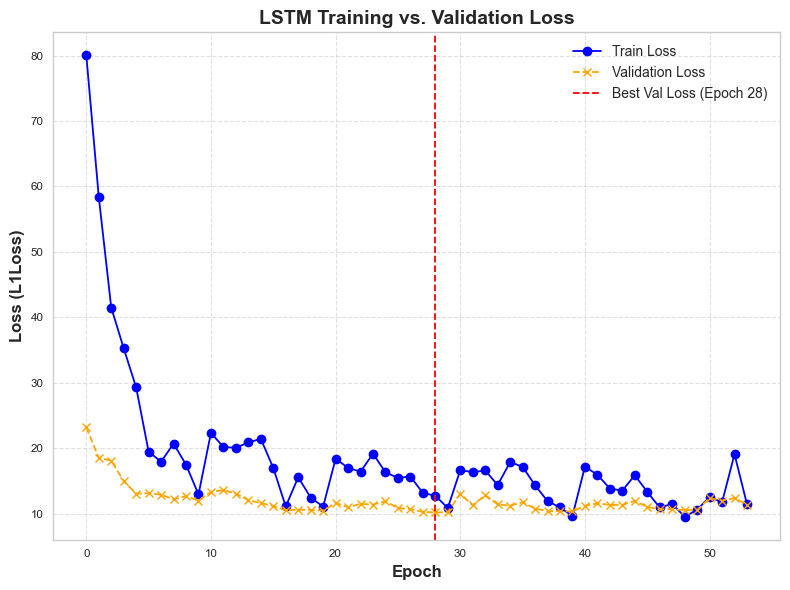


Loss history plot saved to ..\results\lstm_loss_history.png


In [7]:
# Convert history to DataFrame
loss_history_df = pd.DataFrame(time_cb.history)

if not loss_history_df.empty:
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(loss_history_df['epoch'], loss_history_df['train_loss'], label='Train Loss', color='blue', marker='o', linestyle='-')
    ax.plot(loss_history_df['epoch'], loss_history_df['val_loss'], label='Validation Loss', color='orange', marker='x', linestyle='--')

    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')

    ax.set_ylabel('Loss (L1Loss)', fontsize=12, fontweight='bold')
    ax.set_title('LSTM Training vs. Validation Loss', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, which='major', linestyle='--', alpha=0.6)

    # Find epoch with best validation loss and highlight it
    if not loss_history_df['val_loss'].empty:
        best_epoch_idx = loss_history_df['val_loss'].idxmin()
        best_epoch = loss_history_df.loc[best_epoch_idx]
        ax.axvline(x=best_epoch['epoch'], color='red', linestyle='--', label=f"Best Val Loss (Epoch {int(best_epoch['epoch'])})")
        ax.legend()

    # Save the figure
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'lstm_loss_history.png')
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"\nLoss history plot saved to {save_path}")

else:
    print("No loss history was recorded to plot.")

## 6. Evaluate Results

In [8]:
lstm_results_1 = {}

# Use the first asset to determine the number of validation batches (n)
first_asset_name = list(assets_data.keys())[0]
val_ts_len = len(assets_data[first_asset_name]['val_ts'])
n = (val_ts_len - INPUT_CHUNK_LENGTH) // OUTPUT_CHUNK_LENGTH

# Prepare the actuals list once, as it's the same for both models
act_list_full = (
   [assets_data[first_asset_name]['val_ts'][INPUT_CHUNK_LENGTH + i * OUTPUT_CHUNK_LENGTH : INPUT_CHUNK_LENGTH + (i + 1) * OUTPUT_CHUNK_LENGTH] for i in range(n)] 
)
act_list_full = [a for a in act_list_full if len(a) == OUTPUT_CHUNK_LENGTH]

for name, data in assets_data.items():
    try:
        preds_1_raw = lstm_model.historical_forecasts(
            data['val_ts'], 
            past_covariates=data['past_cov_val'],
            future_covariates=data['future_cov_val'],
            start=INPUT_CHUNK_LENGTH, 
            forecast_horizon=OUTPUT_CHUNK_LENGTH,
            stride=OUTPUT_CHUNK_LENGTH, 
            retrain=False, 
            verbose=False
        )
        preds_1 = TimeSeries.from_times_and_values(preds_1_raw.time_index, preds_1_raw.values().astype(np.float32), columns=preds_1_raw.columns)

        # Create lists of individual forecast
        pred_list_1 = [preds_1[i * OUTPUT_CHUNK_LENGTH : (i + 1) * OUTPUT_CHUNK_LENGTH] for i in range(len(preds_1) // OUTPUT_CHUNK_LENGTH)]

        # Evaluate sMAPE for each model
        if pred_list_1 and act_list_full:
            lstm_results_1[name] = evaluate_with_smape(pred_list_1, act_list_full)
    except Exception as e:
        print(f"Error during evaluation for {name}: {e}")
        lstm_results_1[name] = {t: np.nan for t in TARGET_COLS}

if lstm_results_1:
    # Calculate overall, filtering out NaN values
    lstm_overall_1 = {}
    for t in TARGET_COLS:
        values = [r[t] for r in lstm_results_1.values() if not np.isnan(r[t]) and not np.isinf(r[t])]
        lstm_overall_1[t] = np.mean(values) if len(values) > 0 else np.nan
    
    # Overall mean across all non-NaN targets
    valid_values_1 = [v for v in lstm_overall_1.values() if not np.isnan(v) and not np.isinf(v)]
    LSTM_TARGET_1 = np.mean(valid_values_1) if len(valid_values_1) > 0 else np.inf

    print("\n" + "="*40)
    print("           PERFORMANCE SUMMARY")
    print("="*40)
    print(f"Naive Baseline sMAPE: {NAIVE_TARGET:.2f}%")
    print(f"LSTM v1 sMAPE:        {LSTM_TARGET_1:.2f}%")
    print("="*40)
    
    if LSTM_TARGET_1 < NAIVE_TARGET:
        print("\nSUCCESS: LSTM model beat the naive baseline!")
    else:
        print("\nFAILURE: LSTM model could not beat the naive baseline.")
else:
    print("ERROR: No LSTM results were generated!")
    LSTM_TARGET_1 = np.inf

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - C


           PERFORMANCE SUMMARY
Naive Baseline sMAPE: 48.85%
LSTM v1 sMAPE:        91.34%

FAILURE: LSTM model could not beat the naive baseline.


## 7. Save Results

In [11]:
results = {
    'models': {
        'naive': {'overall_smape': float(NAIVE_TARGET), 'per_target': {t: float(v) for t, v in naive_overall.items()}},
        'lstm_v1': {'overall_smape': float(LSTM_TARGET_1), 'per_target': {t: float(v) for t, v in lstm_overall_1.items()}},
    },
    'best_lstm_beats_naive': bool(LSTM_TARGET_1 < NAIVE_TARGET)
}

# Ensure all float values are JSON serializable
results['models']['naive']['overall_smape'] = float(results['models']['naive']['overall_smape'])
results['models']['lstm_v1']['overall_smape'] = float(results['models']['lstm_v1']['overall_smape'])
  
with open(os.path.join(RESULTS_DIR, 'baseline_summary.json'), 'w') as f:
    json.dump(results, f, indent=4)
print(f"\nResults saved to {os.path.join(RESULTS_DIR, 'baseline_summary.json')}")


Results saved to ..\results\baseline_summary.json
